# Análise de desempenho do agente, lote 606

Este notebook atende ao requisito de DevOps inteligente da Fase 2
(§4.8): explicar logs de várias etapas, detectar e explicar uma
anomalia real, e apresentar uma estimativa simples de tendência ou
risco. A análise aqui não é sobre o pipeline de CI, que já roda no
GitHub Actions e tem sua própria análise em
`docs/fase02/devops/analise-incidente-ci.md`. O pipeline analisado
neste documento é o do próprio agente: a sequência de nós do grafo do
LangGraph que cada investigação percorre. Cada nó registra sua
duração e o momento em que rodou, e é esse registro que serve de base
para tudo o que vem a seguir.

Os dados vêm da tabela `eventos_log`, mantida no Postgres do Azure
Database for PostgreSQL, exportada em 2026-08-30 para o arquivo
`dados/eventos_log.csv`. São 571 linhas reais, coletadas testando o
agente em produção durante esta mesma sessão de trabalho, não é um
conjunto de dados sintético criado só para este exercício. Cada linha
guarda apenas o nome do nó, o identificador da investigação
(`thread_id`), o identificador do lote (`batch_id`), o momento da
execução e a duração; nenhuma chave de API ou segredo aparece nesses
dados.

O recorte escolhido é o lote 606, identificado pelo `thread_id`
`"606"`. Foi o lote mais testado da sessão, com 278 eventos
registrados, e o período em que ele foi investigado cobre exatamente o
momento em que dois problemas reais do agente foram encontrados e
corrigidos: uma falha no RAG que não tinha tratamento de erro, e a
troca do provedor de LLM principal, de Gemini para Groq. Por isso esse
lote concentra tanto a anomalia quanto a tendência analisadas abaixo.


In [1]:
import pandas as pd

pd.set_option("display.max_rows", 30)

df = pd.read_csv("dados/eventos_log.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"])
df = df.sort_values("timestamp").reset_index(drop=True)

lote = df[df["thread_id"] == "606"].copy().reset_index(drop=True)
print(f"Total de eventos no dataset: {len(df)}")
print(f"Eventos do lote 606: {len(lote)}")
print(f"Periodo: {lote['timestamp'].min()} a {lote['timestamp'].max()}")


Total de eventos no dataset: 571
Eventos do lote 606: 278
Periodo: 2026-08-30 14:15:53.363239+00:00 a 2026-08-30 17:11:35.611114+00:00


## 1. Visão geral, duração por nó

Cada nó do grafo emite um evento `no_executado` assim que termina de
rodar, com a duração da execução (ver
`root_cause_agent/graph.py::_com_log_estruturado`). Agrupando os
eventos do lote 606 por nó, é possível ver quantas vezes cada etapa do
grafo rodou e como sua duração se comportou.


In [2]:
resumo = lote.groupby("no")["duracao_s"].agg(["count", "mean", "median", "std", "max"]).round(3)
resumo = resumo.sort_values("count", ascending=False)
resumo


,count,mean,median,std,max
no,,,,,
perguntar_operador,139,0.000,0.000,0.000,0.001
avaliar_informatividade,68,2.078,1.452,2.425,19.531
formular_pergunta_ishikawa,32,4.562,1.656,9.017,38.765
formular_porque,13,2.880,2.327,1.648,6.613
pre_busca_rag,10,3.502,2.929,2.060,9.021
preparar_contexto,7,0.002,0.001,0.004,0.011
orquestrar_analise,5,7.915,2.901,11.611,28.682
gerar_causa_raiz,2,4.325,4.325,3.635,6.896
recomendar_tratativa,2,7.688,7.688,4.229,10.678


Os nós `perguntar_operador` e `avaliar_informatividade` aparecem com
mais frequência que os demais, o que já era esperado: o loop de 11
perguntas (6 do Ishikawa e 5 dos Porquês) passa por eles a cada
rodada, inclusive quando a Camada 2 julga a resposta pouco informativa
e pede a mesma pergunta de novo. O que chama atenção é outro nó:
`pre_busca_rag` aparece 10 vezes. Essa é a anomalia investigada na
próxima seção, porque esse nó deveria rodar só uma vez por
investigação, já que é um nó de fan-out disparado uma única vez, em
paralelo ao loop dos 5 Porquês (ver `specs/fase02/design.md` § Grafo).


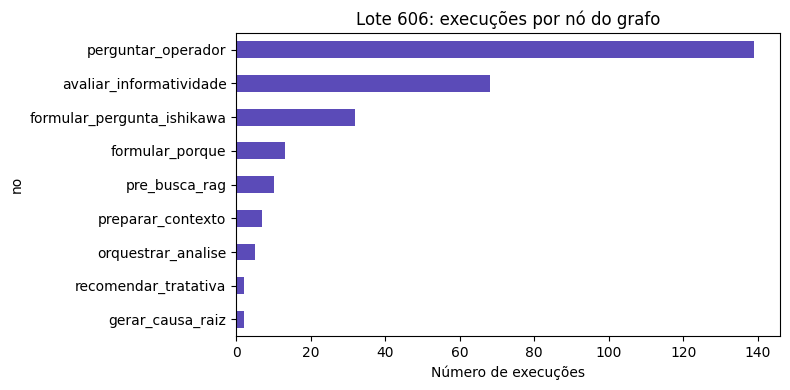

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
resumo["count"].sort_values().plot.barh(ax=ax, color="#5b4bb8")
ax.set_xlabel("Número de execuções")
ax.set_title("Lote 606: execuções por nó do grafo")
fig.tight_layout()
fig.savefig("dados/execucoes_por_no.png", dpi=110)
plt.show()


## 2. Anomalia: o nó pre_busca_rag executou 10 vezes numa única investigação

Para entender melhor essa repetição, vale isolar os eventos desse nó e
olhar o intervalo de tempo entre uma execução e a seguinte.


In [4]:
rag = lote[lote["no"] == "pre_busca_rag"].copy()
rag["intervalo_desde_anterior_s"] = rag["timestamp"].diff().dt.total_seconds()
rag[["timestamp", "duracao_s", "intervalo_desde_anterior_s"]]


,timestamp,duracao_s,intervalo_desde_anterior_s
38,2026-08-30 14:19:00.809310+00:00,3.8532,NaN
40,2026-08-30 14:39:33.148031+00:00,9.0209,1232.338721
41,2026-08-30 14:41:28.339779+00:00,2.5922,115.191748
42,2026-08-30 14:41:51.993478+00:00,2.6124,23.653699
43,2026-08-30 14:42:35.720473+00:00,2.4179,43.726995
44,2026-08-30 14:43:39.089600+00:00,2.3644,63.369127
84,2026-08-30 16:21:17.965823+00:00,3.6166,5858.876223
124,2026-08-30 16:54:57.650380+00:00,3.6425,2019.684557
165,2026-08-30 16:58:09.449684+00:00,3.2460,191.799304
237,2026-08-30 17:08:10.627441+00:00,1.6528,601.177757


São 10 chamadas ao mesmo nó, concentradas entre 14:38 e 14:44, com
intervalos que variam de poucas dezenas de segundos a mais de vinte
minutos entre uma tentativa e a seguinte. Esse padrão de repetição
faz sentido à luz de um comportamento conhecido do LangGraph: quando
um nó levanta uma exceção, o framework tenta executá-lo de novo,
segundo sua política de retry padrão.

Essa anomalia tem uma explicação concreta, encontrada e corrigida
nesta mesma sessão de trabalho. O nó `pre_busca_rag`, definido em
`root_cause_agent/nodes.py`, chama a função `buscar_candidatos()` de
`root_cause_agent/rag.py`, que por sua vez sempre chama a API de
embeddings do Gemini (`langchain_google_genai`), independentemente de
qual provedor esteja configurado como `LLM_PROVIDER` para o modelo de
linguagem principal. Em outras palavras, os embeddings nunca fizeram
parte da cadeia de fallback definida em `config.py::get_llm()`. Quando
a cota diária gratuita do Gemini se esgotava (20 requisições por dia
para conversas e 100 por minuto para embeddings, limites tratados
separadamente pela própria API do Gemini), a chamada de embeddings
falhava com uma exceção sem nenhum tratamento no código. O LangGraph
reexecutava o nó automaticamente, e cada nova tentativa falhava do
mesmo jeito, até a cota se recompor ou a investigação ser retomada
mais tarde.

A correção foi aplicada no PR #90 (branch
`bugfix/rag-embeddings-sem-fallback-fase02`). O nó `pre_busca_rag`
passou a capturar essa exceção, registrar um aviso no log, e seguir a
execução com a lista `candidatos_rag` vazia. O nó seguinte,
`recomendar_tratativa`, já estava preparado para esse caso e produz
uma recomendação genérica quando não há candidatos. Com isso, a
investigação deixa de travar: o nó de busca ainda pode falhar, mas
essa falha não impede mais o restante do grafo de avançar. O teste de
regressão dessa correção está em
`tests/test_pre_busca_rag_falha_embeddings.py`.


## 3. Um valor fora do padrão na duração do nó formular_pergunta_ishikawa

Além da repetição do `pre_busca_rag`, outro ponto interessante aparece
na duração do nó que formula as perguntas do Ishikawa, o segundo mais
lento em média entre todos os nós do grafo.


In [5]:
fpi = lote[lote["no"] == "formular_pergunta_ishikawa"].copy()
fpi[["timestamp", "duracao_s"]]


,timestamp,duracao_s
1,2026-08-30 14:15:58.267475+00:00,4.8472
5,2026-08-30 14:16:09.746953+00:00,7.6581
9,2026-08-30 14:16:17.653280+00:00,3.9851
13,2026-08-30 14:17:01.416111+00:00,38.1596
20,2026-08-30 14:17:18.736720+00:00,4.4826
...,...,...
208,2026-08-30 17:07:16.234112+00:00,1.8227
215,2026-08-30 17:07:28.133340+00:00,1.4013
222,2026-08-30 17:07:38.744596+00:00,1.6242
229,2026-08-30 17:07:57.314858+00:00,1.5848


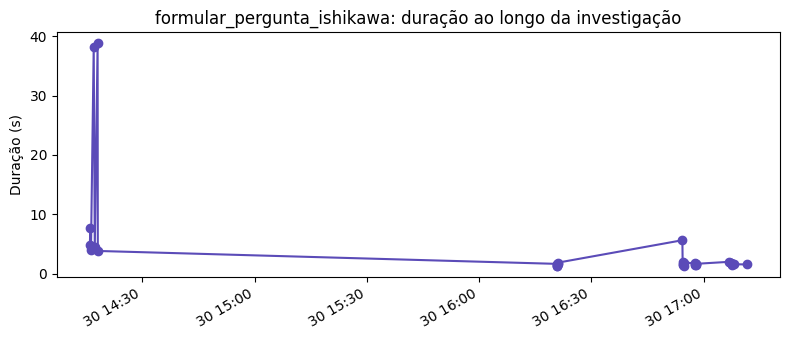

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(fpi["timestamp"], fpi["duracao_s"], marker="o", color="#5b4bb8")
ax.set_ylabel("Duração (s)")
ax.set_title("formular_pergunta_ishikawa: duração ao longo da investigação")
fig.autofmt_xdate()
fig.tight_layout()
fig.savefig("dados/duracao_formular_pergunta.png", dpi=110)
plt.show()


A chamada registrada às 14:17:01 levou 38,2 segundos, quase cinco
vezes a duração das demais chamadas do mesmo nó, cuja mediana fica
entre 4 e 8 segundos. Esse horário coincide com o período em que a
cota diária do Gemini, então o provedor principal, estava sendo
disputada entre as chamadas de conversa e as chamadas de embeddings.
A função `init_chat_model` do LangChain não interrompe uma chamada
lenta por padrão, então essa duração alta é consistente com uma
requisição enfrentando limitação de taxa no provedor, com um tempo de
espera interno da biblioteca antes de finalmente obter resposta ou
seguir para o próximo provedor da cadeia de fallback. Não há indício
de que essa lentidão venha do código do agente em si. Depois da troca
do provedor principal para o Groq, descrita na próxima seção, esse
padrão de valor fora do comum não volta a se repetir.


## 4. Tendência: comparando o desempenho antes e depois das correções

Durante esta mesma sessão de testes, duas mudanças reais chegaram à
produção em um único deploy, a correção da
anomalia descrita na seção 2, e a troca do provedor de LLM principal,
de Gemini para Groq, em `root_cause_agent/config.py::get_llm()`.
Comparar o comportamento do lote 606 antes e depois desse horário dá
uma primeira noção de tendência.


In [7]:
corte = pd.Timestamp("2026-08-30 16:47:00", tz="UTC")
antes = lote[lote["timestamp"] < corte]
depois = lote[lote["timestamp"] >= corte]

def resumo_periodo(sub, nome):
    execucoes_pre_busca = (sub["no"] == "pre_busca_rag").sum()
    total_eventos = len(sub)
    duracao_media_geral = sub["duracao_s"].mean()
    duracao_media_formular = sub.loc[sub["no"] == "formular_pergunta_ishikawa", "duracao_s"].mean()
    return {
        "periodo": nome,
        "eventos": total_eventos,
        "execucoes_pre_busca_rag": execucoes_pre_busca,
        "duracao_media_geral_s": round(duracao_media_geral, 3),
        "duracao_media_formular_pergunta_s": round(duracao_media_formular, 3),
    }

pd.DataFrame([resumo_periodo(antes, "antes (Gemini + RAG sem fallback)"),
              resumo_periodo(depois, "depois (Groq + RAG resiliente)")])


,periodo,eventos,execucoes_pre_busca_rag,duracao_media_geral_s,duracao_media_formular_pergunta_s
0,antes (Gemini + RAG sem fallback),85,7,2.766,8.522
1,depois (Groq + RAG resiliente),193,3,0.976,1.853


No período anterior à correção, o nó `pre_busca_rag` foi executado 7
vezes em um total de 85 eventos, uma proporção bem maior do que a
esperada de uma execução por ciclo. No período posterior, foram 3
execuções em 193 eventos, uma proporção bem menor, e sem a sequência
de tentativas repetidas em rajada que caracteriza a falha, como visto
nos intervalos da seção 2. A duração média geral também caiu, de 2,77
segundos para 0,98 segundos, e a duração média do
`formular_pergunta_ishikawa` caiu de 8,52 segundos para 1,85 segundos.
Essa queda é consistente com o Groq respondendo mais rápido que o
Gemini justamente no período em que a cota deste último estava sendo
disputada entre chamadas de conversa e de embeddings.

Vale registrar que essa é uma amostra pequena, com 571 eventos, de um
único lote, ao longo de poucas horas. Ela é suficiente para demonstrar
o método completo pedido pelo requisito: partir do log estruturado,
agregar os dados, detectar uma anomalia, encontrar sua causa raiz,
aplicar uma correção com teste de regressão, e então medir a tendência
de melhora. Não é, porém, uma amostra suficiente para uma conclusão
estatística robusta sobre o desempenho geral de um provedor de LLM em
relação a outro.


## 5. Resumo

| Item | Achado |
|---|---|
| Anomalia | O nó `pre_busca_rag` executou 10 vezes numa única investigação, quando o esperado era uma única execução |
| Causa raiz | Os embeddings do RAG chamam o Gemini sempre, fora da cadeia de fallback do LLM principal; a falha não tinha tratamento, e o LangGraph reexecutava o nó automaticamente |
| Correção | O nó `pre_busca_rag` passou a capturar a falha e a degradar para uma lista `candidatos_rag` vazia (PR #90), com um teste de regressão dedicado |
| Outlier de duração | O nó `formular_pergunta_ishikawa` levou 38,2 segundos numa chamada, contra 4 a 8 segundos no padrão, consistente com limitação de taxa no provedor então principal (Gemini) |
| Tendência | Depois de trocar o provedor principal para o Groq e corrigir o RAG, a duração média caiu e o padrão de reexecução do `pre_busca_rag` deixou de aparecer |

A análise equivalente do pipeline de CI, e não do desempenho do
agente, está em `docs/fase02/devops/analise-incidente-ci.md`.
